model two loan model classification 


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
df = pd.read_csv('loan_approval_dataset.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [58]:
df.info()
 
  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [59]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [60]:
df.drop(columns=['loan_id'], axis=1, inplace=True)

In [82]:
  
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()

In [62]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0


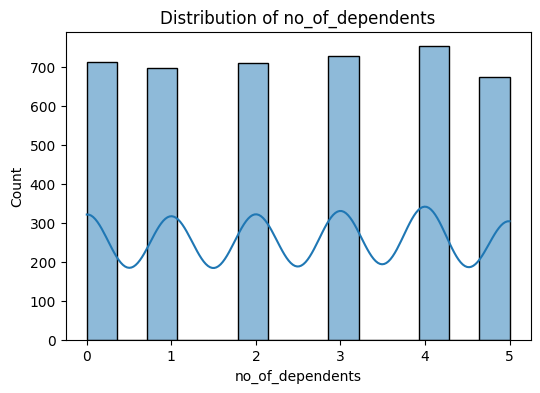

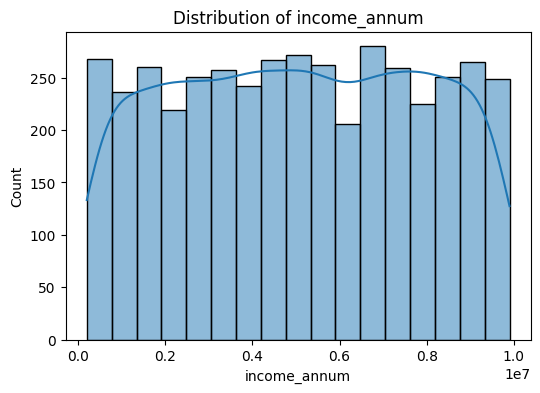

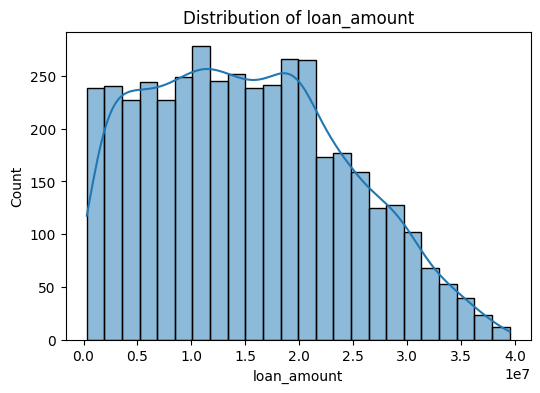

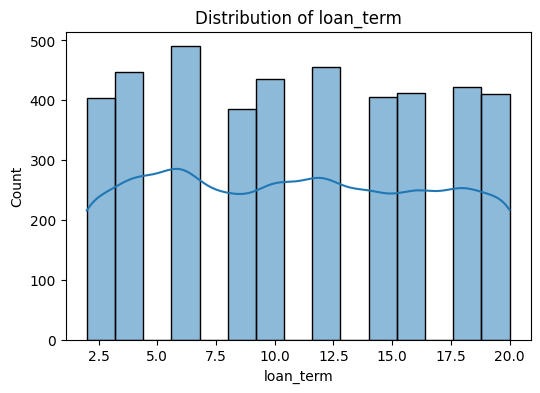

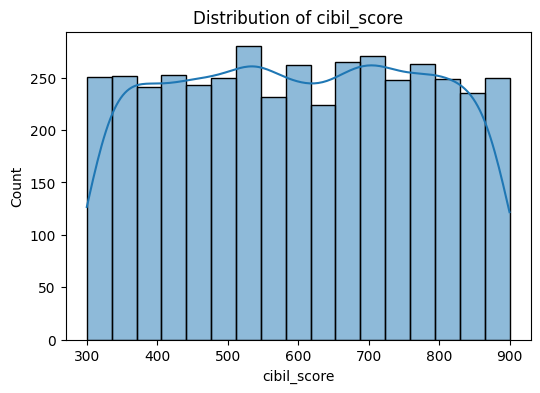

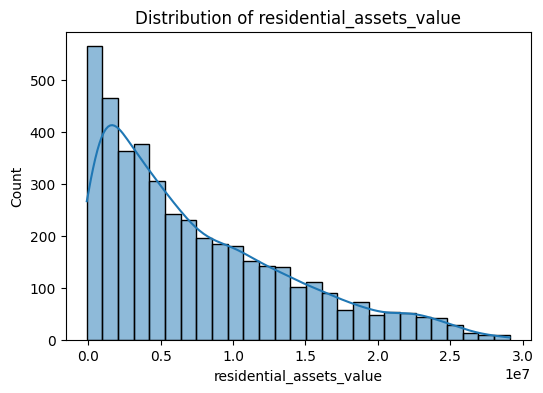

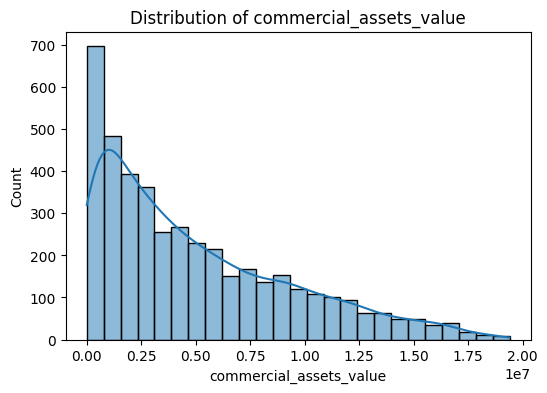

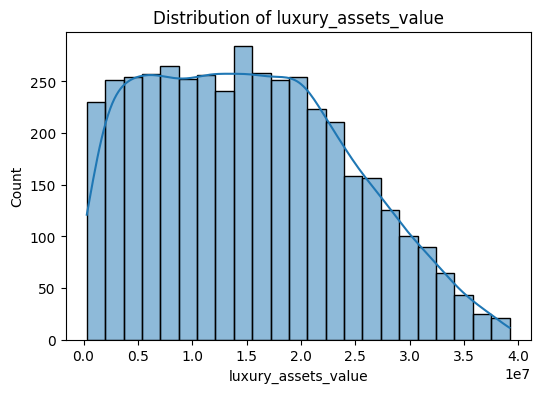

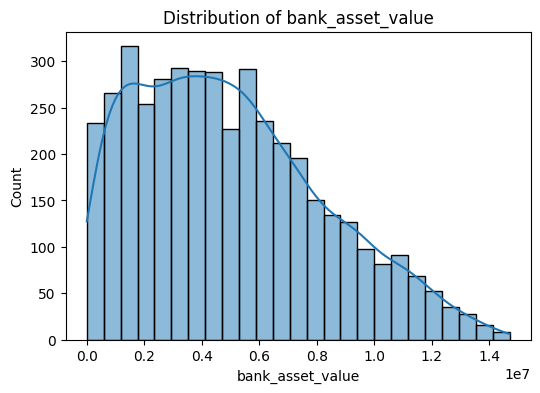

In [63]:
for col in df.columns:
    if df[col].dtype != 'O':
        plt.figure(figsize=(6,4))
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.show()

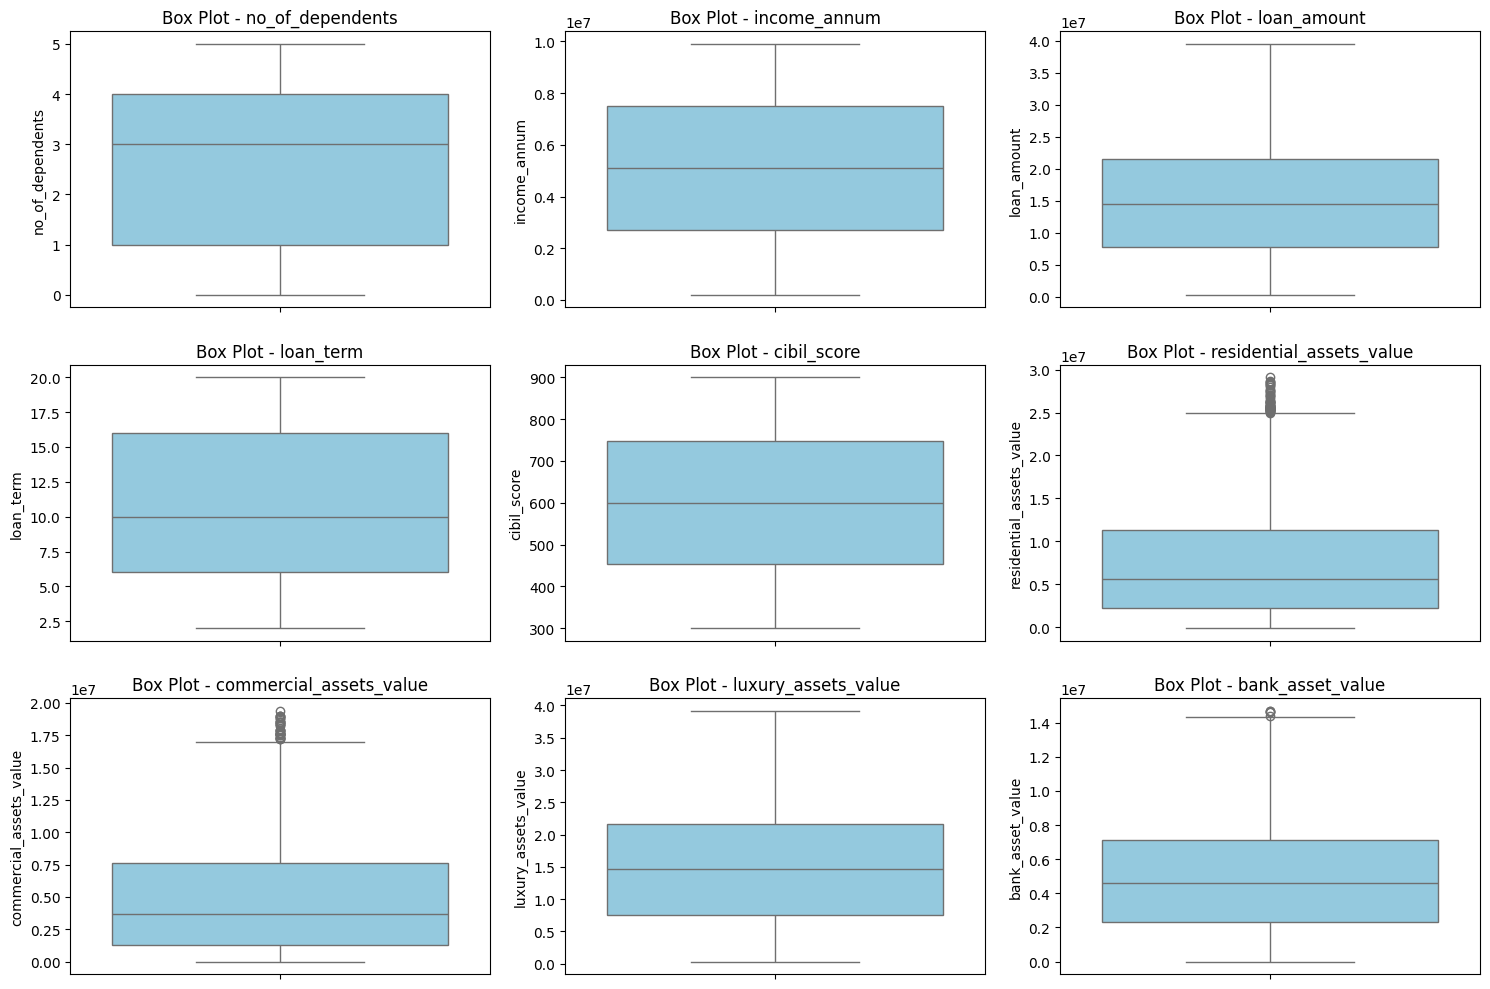

In [72]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Box Plot - {col}')
plt.tight_layout()
plt.show()
    
    

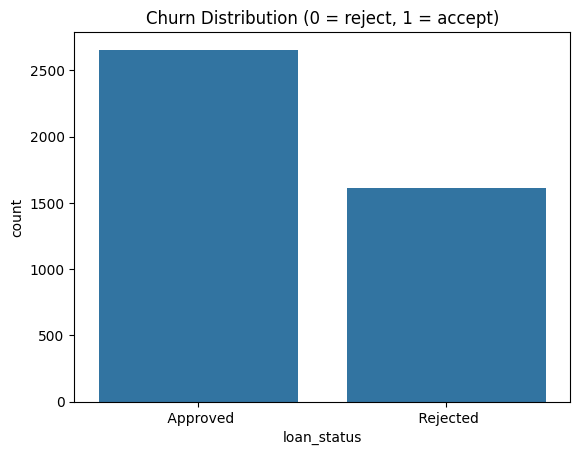

In [74]:
sns.countplot(x='loan_status', data=df)
plt.title("Churn Distribution (0 = reject, 1 = accept)")
plt.show()

In [65]:
df.describe(include='O')

,education,self_employed,loan_status
count,4269,4269,4269
unique,2,2,2
top,Graduate,Yes,Approved
freq,2144,2150,2656


In [119]:
categories = df.select_dtypes(include=['object']).columns
for col in categories:
    print(f"value counts for:\n{df[col].value_counts()}\n")
    print("-" * 40)

value counts for:
education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

----------------------------------------
value counts for:
self_employed
Yes    2150
No     2119
Name: count, dtype: int64

----------------------------------------
value counts for:
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

----------------------------------------


In [120]:
## get all the numeric features
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
print('Num of Numerical Features :', len(num_features))
print('Numerical Features :', num_features)

Num of Numerical Features : 9
Numerical Features : ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


In [121]:
cat_features  = [feature for feature in df.columns if df[feature].dtype == 'O']
print("num of feature is : " , len (cat_features))

num of feature is :  3


In [165]:
from sklearn.model_selection import train_test_split
# افترض أن df هو الداتا الأصلية
X = df.drop('loan_status', axis=1)  # أو الاسم الصحيح حسب الداتا
y = df['loan_status']

# طباعة الأعمدة للتأكد
print("Columns:", X.columns.tolist())
print(len(X.columns))

Columns: ['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
11


In [166]:
# separate dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

 


In [167]:
# Function to calculate outliers using IQR
def detect_outliers_iqr(data, feature):
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
    return outliers

# Check outliers in each numerical column
for col in num_features:
    outliers = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers")

no_of_dependents: 0 outliers
income_annum: 0 outliers
loan_amount: 0 outliers
loan_term: 0 outliers
cibil_score: 0 outliers
residential_assets_value: 52 outliers
commercial_assets_value: 37 outliers
luxury_assets_value: 0 outliers
bank_asset_value: 5 outliers


In [ ]:
# Create Column Transformer with 3 types of transformers
cat_features = X.select_dtypes(include="object").columns
num_features = X.select_dtypes(exclude="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop='first')
#oh_transformer = OneHotEncoder(handle_unknown='ignore', drop='first')    # its more pest for project 


preprocessor = ColumnTransformer(
    [
         ("OneHotEncoder", oh_transformer, cat_features),
          ("StandardScaler", numeric_transformer, num_features)
    ]
)

In [169]:
preprocessor

,transformers,"[('OneHotEncoder', ...), ('StandardScaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'first'
,sparse_output,True


In [170]:
pd.DataFrame(X_train)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
1675,5,Not Graduate,No,7900000,29900000,6,568,5800000,13900000,15900000,8700000
1164,0,Not Graduate,Yes,9600000,34000000,12,710,23800000,10300000,38100000,7800000
192,1,Graduate,No,800000,2900000,8,682,2200000,1100000,2900000,700000
910,2,Graduate,Yes,4900000,13100000,18,754,8200000,3300000,16500000,7200000
567,5,Graduate,Yes,3000000,11100000,12,441,8500000,2500000,7300000,2000000
...,...,...,...,...,...,...,...,...,...,...,...
3444,0,Graduate,Yes,1300000,4700000,16,530,3200000,1000000,3800000,800000
466,5,Not Graduate,Yes,500000,1800000,18,411,1000000,500000,1300000,200000
3092,4,Not Graduate,Yes,8600000,20600000,16,449,10800000,10600000,28700000,5400000
3772,2,Not Graduate,Yes,7000000,21400000,12,541,3700000,1300000,19800000,9600000


In [171]:
y_train = y_train.str.strip()
y_test = y_test.str.strip()

# تحويل القيم النصية لأرقام
y_train = y_train.map({'Approved': 1, 'Rejected': 0})
y_test = y_test.map({'Approved': 1, 'Rejected': 0})

In [172]:
X_train = preprocessor .fit_transform(X_train)
X_test = preprocessor.transform(X_test)


In [178]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score,roc_curve 
import mlflow
import joblib

In [184]:
# Initialize the XGBoost classifier
mlflow.set_experiment("Loan_Approval_XGBoost")
with mlflow.start_run():   
 xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    max_depth=3,
    learning_rate=0.1,
    n_estimators=100,
    verbosity=1
)

# Train the classifier
xgb_clf.fit(X_train, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [185]:
y_train_pred = xgb_clf.predict(X_train)
y_test_pred = xgb_clf .predict(X_test)

    # Training set performance
model_train_accuracy = accuracy_score(y_train, y_train_pred) # Calculate Accuracy
model_train_f1 = f1_score(y_train, y_train_pred, average='weighted') # Calculate F1-score
model_train_precision = precision_score(y_train, y_train_pred) # Calculate Precision
model_train_recall = recall_score(y_train, y_train_pred) # Calculate Recall
model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)


In [186]:
model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
model_test_precision = precision_score(y_test, y_test_pred) # Calculate Precision
model_test_recall = recall_score(y_test, y_test_pred) # Calculate Recall
model_test_rocauc_score = roc_auc_score(y_test, y_test_pred) #Calculate Roc


In [187]:
print('Model performance for Training set')
print("- Accuracy: {:.4f}".format(model_train_accuracy))
print('- F1 score: {:.4f}'.format(model_train_f1))
    
print('- Precision: {:.4f}'.format(model_train_precision))
print('- Recall: {:.4f}'.format(model_train_recall))
print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    
    
print('----------------------------------')
    
print('Model performance for Test set')
print('- Accuracy: {:.4f}'.format(model_test_accuracy))
print('- F1 score: {:.4f}'.format(model_test_f1))
print('- Precision: {:.4f}'.format(model_test_precision))
print('- Recall: {:.4f}'.format(model_test_recall))
print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    
 

Model performance for Training set
- Accuracy: 0.9918
- F1 score: 0.9918
- Precision: 0.9874
- Recall: 0.9995
- Roc Auc Score: 0.9893
----------------------------------
Model performance for Test set
- Accuracy: 0.9696
- F1 score: 0.9695
- Precision: 0.9670
- Recall: 0.9851
- Roc Auc Score: 0.9642


In [192]:
mlflow.log_metric("accuracy", model_train_accuracy )
 
mlflow.sklearn.log_model(xgb_clf, "xgb_model")
 

2025/10/09 19:11:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/09 19:12:23 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [194]:
joblib.dump(xgb_clf, "xgb_loan_model.pkl")


['xgb_loan_model.pkl']

In [195]:
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']